# Galaxy Image Simulation, Detection, and Morphological Fitting
## From pixels to physical parameters

**Simulator:** GalSim — [https://galsim-developers.github.io/GalSim/_build/html/index.html](https://galsim-developers.github.io/GalSim/_build/html/index.html)  
**Detection & fitting:** photutils — [https://photutils.readthedocs.io/en/stable/](https://photutils.readthedocs.io/en/stable/)  
**Profile model:** `astropy.modeling.models.Sersic2D`  
**Reference (GalSim):** Rowe et al. (2015), Astronomy and Computing, 10, 121 — [arXiv:1407.7676](https://arxiv.org/abs/1407.7676)  
**Reference (GALFIT):** Peng et al. (2002), AJ 124, 266 — [arXiv:astro-ph/0204182](https://arxiv.org/abs/astro-ph/0204182)  
**Reference (Sérsic profile):** Sérsic (1963), Boletin de la Asociacion Argentina de Astronomia, 6, 41

---

## Learning objectives

After this tutorial you will be able to:
1. Describe the **Sérsic surface-brightness profile** and its special cases (exponential disk, de Vaucouleurs elliptical).
2. Explain how **atmospheric and instrumental blurring** (the PSF) smears a galaxy image, and why convolution is the right mathematical description.
3. Understand the **noise budget** of a real observation: photon shot noise, sky background, and read noise.
4. Use **GalSim** to simulate a realistic multi-galaxy image field.
5. Detect sources with **photutils** background subtraction and segmentation.
6. Fit a **2-D Sérsic model** to each detected galaxy and recover morphological parameters.
7. Quantify **parameter recovery** (bias and scatter) as a function of signal-to-noise ratio.

---

## 1. Galaxy Surface-Brightness Profiles

### 1.1 The Sérsic profile

The **surface brightness** $I$ of a galaxy is the flux per solid angle (e.g. in units of mag arcsec$^{-2}$ or photons s$^{-1}$ arcsec$^{-2}$). Empirically, nearly all galaxy profiles are well described by the **Sérsic (1963) law**:

$$\boxed{I(r) = I_e \exp\!\left\{-b_n\!\left[\left(\frac{r}{r_e}\right)^{1/n} - 1\right]\right\}}$$

| Symbol | Name | Typical values |
|--------|------|----------------|
| $r$ | Projected radius from centre | 0 → ∞ |
| $r_e$ | Effective (half-light) radius | 0.1–10 arcsec |
| $I_e$ | Surface brightness at $r_e$ | — |
| $n$ | Sérsic index (shape) | 0.5–10 |
| $b_n$ | Normalisation constant | $\approx 2n - 0.327$ |

**Why $b_n$?** The constant $b_n$ is chosen so that $r_e$ encloses exactly half the total luminosity. The exact value solves
$$\Gamma(2n) = 2\,\gamma(2n,\, b_n),$$
where $\Gamma$ is the complete gamma function and $\gamma$ the lower incomplete gamma function. The approximation $b_n \approx 2n - 0.327$ (Graham & Driver 2005, Eq. 9) is accurate to ~1% for $n \geq 1$. The error grows to ~6% at $n = 0.5$, so for $n < 1$ the exact numerical solution (e.g. `scipy.special.gammaincinv(2*n, 0.5)`) should be used. For large $n$ the asymptotic form $b_n \approx 2n - 1/3$ is accurate to 0.1%.

### 1.2 Special cases

- **$n = 1$ — Exponential profile:** $I(r) = I_e\,e^{-b_1(r/r_e - 1)}$, with $b_1 \approx 1.678$.  
  Describes **late-type disk galaxies** (spirals, irregulars). The luminosity decreases exponentially with radius, analogous to the thin stellar disk of the Milky Way.

- **$n = 4$ — de Vaucouleurs (1948) profile:** Proposed before Sérsic's generalisation, with $b_4 \approx 7.67$.  
  Describes **early-type elliptical galaxies** and classical bulges. It has a bright, compact core and extended low-surface-brightness wings — very different from the smooth exponential decline of a disk.

- **$n < 1$:** Flatter central core than exponential (dwarf and irregular galaxies).
- **$n > 4$:** Very concentrated profile (massive compact ellipticals, some bulges).

### 1.3 Elliptical isophotes

Real galaxies are not round. The radius $r$ is replaced by an **elliptical radius**:
$$\tilde{r}(x, y) = \sqrt{x'^2 + \left(\frac{y'}{q}\right)^2}$$
where $(x', y')$ are coordinates **rotated by the position angle** PA (measured east of north), and $q = b/a \in (0, 1]$ is the **axis ratio** ($q = 1$ is round, $q \to 0$ is edge-on disk).

Alternatively, the shape is described by two **ellipticity components**:
$$e_1 = \frac{1-q}{1+q}\cos(2\,\text{PA}), \qquad e_2 = \frac{1-q}{1+q}\sin(2\,\text{PA})$$
with total ellipticity $|e| = \sqrt{e_1^2 + e_2^2} = (1-q)/(1+q)$.

### 1.4 Total flux

Integrating $I(\tilde{r})$ over the elliptical plane gives the total flux (Graham & Driver 2005, Eq. 2):
$$F_\text{tot} = 2\pi\, I_e\, r_e^2\, q\, \frac{n\, e^{b_n}}{b_n^{2n}}\, \Gamma(2n)$$

This follows from the substitution $t = (r/r_e)^{1/n}$ in the radial integral, recognising the integral over $e^{-b_n t} t^{2n-1}$ as $\Gamma(2n)/b_n^{2n}$. This is why $r_e$, $n$, and $I_e$ (or equivalently the total magnitude) are the three key parameters to recover when fitting a galaxy.

---

## 2. The Point Spread Function and Convolution

### 2.1 What is the PSF?

A **point source** (a star infinitely far away) should in principle appear as a single point on the detector. In reality, turbulence in the Earth's atmosphere (**seeing**) and diffraction by the telescope optics **spread** the light over several pixels. The resulting image of a point source is called the **Point Spread Function (PSF)**.

For a ground-based telescope with **Gaussian seeing** (a standard first-order approximation):
$$\text{PSF}(x, y) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

The width is usually quoted as the **Full Width at Half Maximum (FWHM)**:
$$\text{FWHM} = 2\sqrt{2\ln 2}\;\sigma \approx 2.355\;\sigma$$

Typical ground-based seeing: FWHM $\approx 0.5''$–$2''$ (best sites: Mauna Kea, Cerro Paranal $\sim 0.4''$–$0.8''$). Space telescopes remove the atmosphere entirely: HST has FWHM $\approx 0.07''$–$0.14''$ (depending on instrument and filter wavelength); JWST achieves FWHM $\approx 0.03''$–$0.12''$ (from short near-IR at 0.6 μm to mid-IR at 4 μm, set by diffraction from its 6.5 m mirror).

> **Note:** Real PSFs are not perfectly Gaussian. In practice they are measured from bright, unsaturated stars in the science field and modelled empirically (e.g. Moffat profiles, or with the PSFEx software).

### 2.2 Convolution theorem

The observed image is the **convolution** of the true sky brightness with the PSF:
$$I_\text{obs}(x, y) = (I_\text{true} * \text{PSF})(x, y) = \int\!\int I_\text{true}(x', y')\,\text{PSF}(x-x', y-y')\,dx'\,dy'$$

In Fourier space, convolution becomes **multiplication**:
$$\hat{I}_\text{obs}(u, v) = \hat{I}_\text{true}(u, v)\cdot\hat{\text{PSF}}(u, v)$$
This is computationally efficient (use `numpy.fft`) and explains why recovering $I_\text{true}$ from $I_\text{obs}$ (deconvolution) is difficult: dividing by $\hat{\text{PSF}}$ amplifies noise at spatial frequencies where $|\hat{\text{PSF}}| \to 0$.

### 2.3 Effect on morphological parameters

PSF convolution **broadens** the observed profile and makes the galaxy look larger and rounder. If the galaxy's intrinsic half-light radius is comparable to or smaller than the PSF (unresolved), all morphological information is lost. For resolved galaxies:
- **$r_e$ is overestimated** if the PSF is not accounted for in the fit.
- **$n$ is biased toward lower values** (the convolved core looks shallower than the true profile).

This is why fitting must be done in **image space**: convolve the model with the PSF, then compare to the data — not by fitting the 1D radial profile directly.

---

## 3. Image Noise

### 3.1 Photon shot noise

Photons arrive randomly. If on average $\lambda$ photons hit a pixel in an exposure, the actual count follows a **Poisson distribution** $P(k; \lambda) = e^{-\lambda}\lambda^k / k!$ with mean $\lambda$ and variance $\lambda$.

For large $\lambda$ (typically $\lambda > 20$), the Poisson distribution is well approximated by a Gaussian with $\sigma = \sqrt{\lambda}$, so:
$$\sigma_\text{shot} = \sqrt{N_\text{photons}}$$

### 3.2 Sky background

The night sky emits light (moonlight, airglow, zodiacal light, light pollution). A sky background of $S_\text{sky}$ counts per pixel adds Poisson noise:
$$\sigma_\text{sky} = \sqrt{S_\text{sky}}$$

### 3.3 Read noise

Reading out the CCD introduces a Gaussian noise with standard deviation $\sigma_\text{read}$ (typically 3–10 electrons per pixel), independent of signal.

### 3.4 Total noise and SNR

The total noise variance per pixel is:
$$\sigma^2_\text{pixel} = N_\text{gal} + N_\text{sky} + \sigma^2_\text{read}$$

The **signal-to-noise ratio (SNR)** of a source detected in an aperture of $N_\text{pix}$ pixels is:
$$\boxed{\text{SNR} = \frac{\displaystyle\sum_\text{aperture} N_\text{gal}}{\displaystyle\sqrt{\sum_\text{aperture}\left(N_\text{gal} + N_\text{sky} + \sigma^2_\text{read}\right)}}}$$

In the **sky-noise dominated** regime ($N_\text{sky} \gg N_\text{gal}$): $\text{SNR} \approx F_\text{gal} / \sqrt{N_\text{pix}\, S_\text{sky}}$, so fainter and larger galaxies are harder to detect.

---

## 4. Source Detection

### 4.1 Background estimation

The raw image contains both the sources and a spatially varying background (sky gradient, stray light). Before detecting sources, we estimate and subtract this background by computing a **smoothed median map** in a grid of boxes across the image.

### 4.2 Thresholding and segmentation

After background subtraction, pixels above a threshold $\tau = k\,\sigma_\text{bg}$ (typically $k = 1.5$–$3$) are marked as belonging to sources. The **connected components** of above-threshold pixels form a **segmentation map**: each detected object gets a unique integer label.

The number of connected pixels (above a **minimum area** $A_\text{min}$) prevents noise spikes from being catalogued as sources.

### 4.3 Source catalogue

From the segmentation map, we measure properties of each object:
- **Centroid** $(x_0, y_0)$: flux-weighted mean pixel position.
- **Flux** $F$: sum of background-subtracted pixel values in the segment.
- **Semi-major/minor axes** $a, b$: from the second-order moments of the light distribution.
- **Position angle** PA: orientation of the major axis.

---

## 5. Galaxy Profile Fitting

### 5.1 Chi-squared minimisation

We want to find the parameters $\boldsymbol{\theta} = \{x_0, y_0, n, r_e, e_1, e_2, F_\text{tot}\}$ that make the model image $M(i,j;\boldsymbol{\theta})$ (Sérsic profile convolved with PSF) best match the observed image $I_\text{obs}(i,j)$.

The standard measure of goodness-of-fit is:
$$\chi^2(\boldsymbol{\theta}) = \sum_{i,j \in \text{stamp}} \frac{\left[I_\text{obs}(i,j) - M(i,j;\boldsymbol{\theta})\right]^2}{\sigma^2(i,j)}$$

where $\sigma^2(i,j) = I_\text{obs}(i,j) + S_\text{sky} + \sigma^2_\text{read}$ is the noise variance per pixel.

The best-fit parameters $\hat{\boldsymbol{\theta}}$ minimise $\chi^2$:
$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}}\, \chi^2(\boldsymbol{\theta})$$

This is solved numerically with the **Levenberg–Marquardt algorithm** (a hybrid of gradient descent and Newton's method), which is robust for well-behaved non-linear least squares problems.

### 5.2 Residuals

After fitting, the **residual image** is:
$$R(i,j) = I_\text{obs}(i,j) - M(i,j;\hat{\boldsymbol{\theta}})$$

If the model is correct and the noise is Gaussian, the residuals should look like white noise with zero mean. Systematic patterns in the residuals (e.g. ring-shaped residuals) indicate the model is inadequate.

### 5.3 Professional tools

In research, the standard tool for galaxy profile fitting is **GALFIT** (Peng et al. 2002, 2010), a compiled Fortran code that fits multiple Sérsic components simultaneously, including PSF deconvolution. The Python package [GALFITools](https://pypi.org/project/GALFITools/) provides utilities to prepare GALFIT input files and analyse GALFIT outputs. In this tutorial we use the pure-Python `astropy.modeling` approach, which is equivalent for single-component fits.

---

## 6. Setup and Imports

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Core scientific stack ────────────────────────────────────────────────────
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from scipy.special import gamma as gamma_func, gammainc

# ── Astronomy ────────────────────────────────────────────────────────────────
import astropy
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.convolution import Gaussian2DKernel, convolve_fft
from astropy.nddata import Cutout2D
from astropy.table import Table

# ── Galaxy image simulator ────────────────────────────────────────────────────
import galsim

# ── Source detection and photometry ──────────────────────────────────────────
import photutils
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.aperture import CircularAperture

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'image.origin': 'lower',
})

RNG = default_rng(42)  # reproducible random numbers

print('Imports successful!')
print(f'astropy  {astropy.__version__}')
print(f'photutils {photutils.__version__}')
print(f'galsim   {galsim.__version__}')

Imports successful!
astropy  7.2.0
photutils 3.0.0
galsim   2.8.4


### 6.1 Global simulation parameters

We define all physical parameters of the simulated observation here. Changing these values allows you to explore different noise regimes and telescope configurations.

In [2]:
# ── Telescope / detector ──────────────────────────────────────────────────────
PIXEL_SCALE  = 0.2          # arcsec / pixel  (e.g. VLT/HAWK-I)
IMAGE_SIZE   = 512          # pixels per side
PSF_FWHM     = 0.8          # arcsec  ("seeing")
PSF_SIGMA_PX = (PSF_FWHM / PIXEL_SCALE) / (2 * np.sqrt(2 * np.log(2)))
READ_NOISE   = 5.0          # electrons per pixel (rms)

# ── Sky background ────────────────────────────────────────────────────────────
SKY_LEVEL    = 200.0        # counts / pixel  (sky + dark current)

# ── Galaxy population ─────────────────────────────────────────────────────────
N_GALAXIES   = 30           # number of galaxies to simulate

print('Simulation parameters:')
print(f'  Image size      : {IMAGE_SIZE} × {IMAGE_SIZE} px')
print(f'  Pixel scale     : {PIXEL_SCALE}" / px')
print(f'  Field of view   : {IMAGE_SIZE * PIXEL_SCALE / 60:.2f} arcmin × {IMAGE_SIZE * PIXEL_SCALE / 60:.2f} arcmin')
print(f'  PSF FWHM        : {PSF_FWHM}" ({PSF_FWHM / PIXEL_SCALE:.1f} px)')
print(f'  PSF sigma       : {PSF_SIGMA_PX:.2f} px')
print(f'  Sky level       : {SKY_LEVEL} counts/px')
print(f'  Read noise      : {READ_NOISE} e- rms')
print(f'  N galaxies      : {N_GALAXIES}')

Simulation parameters:
  Image size      : 512 × 512 px
  Pixel scale     : 0.2" / px
  Field of view   : 1.71 arcmin × 1.71 arcmin
  PSF FWHM        : 0.8" (4.0 px)
  PSF sigma       : 1.70 px
  Sky level       : 200.0 counts/px
  Read noise      : 5.0 e- rms
  N galaxies      : 30


---

## 7. Visualising the Sérsic Profile

Before simulating images, let us build intuition by plotting $I(r)$ for different Sérsic indices. We normalise so that all profiles have the same effective radius $r_e = 1$ and the same total flux.

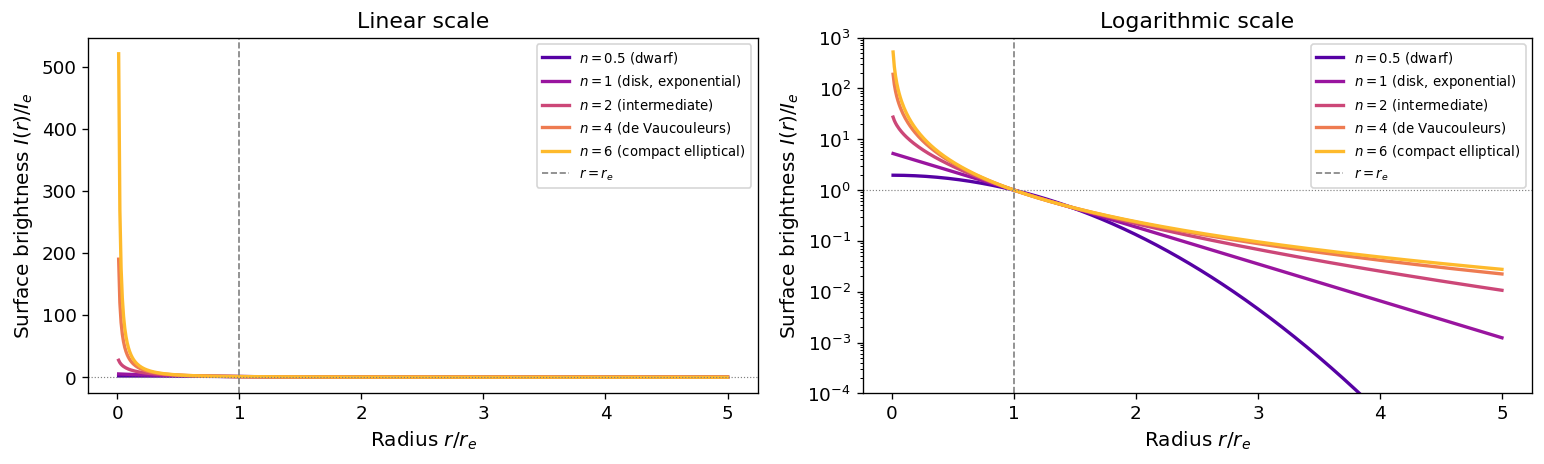

Observation: higher n → steeper inner profile and more extended wings.
At r = r_e, ALL profiles cross I = I_e by definition.


In [3]:
def b_n(n):
    """Approximation b_n ≈ 2n − 0.327 (Graham & Driver 2005).
    Accurate to ~1% for n ≥ 1; error grows to ~6% at n = 0.5.
    For n < 1 use: scipy.special.gammaincinv(2*n, 0.5)
    """
    return 2.0 * n - 0.327

def sersic_profile(r, n, r_e=1.0, I_e=1.0):
    """Sérsic profile I(r)."""
    bn = b_n(n)
    return I_e * np.exp(-bn * ((r / r_e)**(1.0 / n) - 1.0))

# ── Plot: Sérsic profiles for n = 0.5, 1, 2, 4, 6 ───────────────────────────
r = np.linspace(0.01, 5, 500)
n_values = [0.5, 1.0, 2.0, 4.0, 6.0]
labels   = [r'$n=0.5$ (dwarf)', r'$n=1$ (disk, exponential)',
            r'$n=2$ (intermediate)', r'$n=4$ (de Vaucouleurs)',
            r'$n=6$ (compact elliptical)']
colors   = plt.cm.plasma(np.linspace(0.15, 0.85, len(n_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax in axes:
    for n_val, lbl, col in zip(n_values, labels, colors):
        profile = sersic_profile(r, n_val)
        ax.plot(r, profile, color=col, lw=2, label=lbl)
    ax.axvline(1.0, color='gray', lw=1, ls='--', label=r'$r = r_e$')
    ax.axhline(1.0, color='gray', lw=0.7, ls=':')
    ax.set_xlabel(r'Radius $r / r_e$')
    ax.set_ylabel(r'Surface brightness $I(r) / I_e$')
    ax.legend(fontsize=8)
    ax.set_title('Sérsic surface-brightness profiles')

axes[0].set_yscale('linear')
axes[0].set_title('Linear scale')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-4, 1e3)
axes[1].set_title('Logarithmic scale')

plt.tight_layout()
plt.savefig('galsim_sersic_profiles.pdf', bbox_inches='tight')
plt.show()

print('Observation: higher n → steeper inner profile and more extended wings.')
print('At r = r_e, ALL profiles cross I = I_e by definition.')

---

## 8. Interactive Galaxy Image Explorer

Before diving into the automated pipeline, **play with this widget to build intuition** about all the concepts covered in sections 1–5:

- How do the Sérsic index $n$ and effective radius $r_e$ shape the 2D image?
- How does PSF blurring wash out fine structure — especially for small galaxies?
- What do *good* vs *poor* residuals look like?
- What happens when you start the fit far from the true parameters?

**Instructions:** Set galaxy parameters on the left → click **▶ Generate** → adjust the initial guess sliders in the middle → click **⚙ Fit** → read the fit quality statistics on the right.

> **Requires** the imports and parameters cells (sections 6–6.1) to have been run first.

In [19]:
# ================================================================
# Interactive Galaxy Image Explorer
# Section 8 -- ipywidgets, pure-numpy simulation, astropy fitting
#
# _simulate uses only numpy (numpy.fft Gaussian convolution +
# direct Sersic formula).  astropy.modeling.Sersic2D is used only
# in _fit, where it already works in the later pipeline sections.
#
# Requires: imports cell and params cell (section 6) already run.
# ================================================================
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
from numpy.fft import fft2, ifft2, fftfreq

# -- Shared state ------------------------------------------------------------
_ws          = {}
_click_count = [0]
_STAMP_PX    = 81
_RN          = 5.0
_N_FREE      = 7

# -- Figure renderer (backend-agnostic) --------------------------------------
def _render(fig, dpi=110):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    buf.seek(0)
    w = widgets.Image(value=buf.read(), format='png')
    plt.close(fig)
    return w

# -- Pure-numpy Sersic profile -----------------------------------------------
def _sersic_numpy(xx, yy, cx, cy, re_px, n, q, pa_rad, flux):
    # Sersic 2D via direct numpy formula; exponent clipped to prevent overflow
    dx  = xx.astype(np.float64) - float(cx)
    dy  = yy.astype(np.float64) - float(cy)
    cp  = float(np.cos(pa_rad))
    sp  = float(np.sin(pa_rad))
    xp  =  dx * cp + dy * sp
    yp  = -dx * sp + dy * cp
    r   = np.sqrt(xp**2 + (yp / max(float(q), 1e-3))**2)
    bn  = max(2.0 * float(n) - 0.327, 0.1)
    arg = -bn * ((r / max(float(re_px), 1e-3)) ** (1.0 / max(float(n), 0.05)) - 1.0)
    profile = np.exp(np.clip(arg, -50.0, 50.0))
    s = profile.sum()
    if s > 0:
        profile *= float(flux) / s
    return profile

# -- Gaussian PSF convolution via numpy.fft ----------------------------------
def _gauss_convolve(image, sigma_px):
    # Flux-conserving Gaussian blur using numpy FFT; always finite
    if float(sigma_px) < 0.05:
        return image.copy()
    ny, nx = image.shape
    fy     = fftfreq(ny)[:, None]
    fx     = fftfreq(nx)[None, :]
    kernel = np.exp(-2.0 * np.pi**2 * float(sigma_px)**2 * (fx**2 + fy**2))
    return np.real(ifft2(fft2(image) * kernel))

# -- Full simulation ---------------------------------------------------------
def _simulate(n_val, re_arcsec, flux_val, q_val, pa_deg,
              psf_fwhm_arcsec, sky_val, add_noise, seed):
    sz   = _STAMP_PX
    cx   = sz / 2.0
    yy_, xx_ = np.mgrid[0:sz, 0:sz]
    re_px    = max(float(re_arcsec) / PIXEL_SCALE, 0.5)
    psf_sig  = (float(psf_fwhm_arcsec) / PIXEL_SCALE) / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sky_f    = float(sky_val)
    profile  = _sersic_numpy(xx_, yy_, cx, cx, re_px, n_val, q_val,
                               np.deg2rad(float(pa_deg)), float(flux_val))
    conv     = _gauss_convolve(profile, psf_sig)
    s = conv.sum()
    if s > 0:
        conv *= float(flux_val) / s
    if add_noise:
        rng_  = np.random.default_rng(int(seed))
        lam   = np.maximum(conv + sky_f, 0.0)
        noisy = rng_.poisson(lam).astype(np.float64) - sky_f
        noisy += rng_.normal(0.0, _RN, noisy.shape)
    else:
        noisy = conv.copy()
    sigma = np.sqrt(np.abs(noisy) + sky_f + _RN**2).clip(1e-3)
    return conv, noisy, sigma

# ============================================================================
# Widget controls
# ============================================================================
W = lambda px=275: widgets.Layout(width=f'{px}px')

w_profile = widgets.Dropdown(
    options=[('Disk  (n = 1)', 1.0), ('Elliptical  (n = 4)', 4.0), ('Custom n', None)],
    value=1.0, description='Profile:',
    style={'description_width': '58px'}, layout=W(265))

w_n_cust = widgets.BoundedFloatText(
    value=1.0, min=0.3, max=6.0, step=0.1, description='n:',
    style={'description_width': '22px'}, layout=W(105), disabled=True)

w_re = widgets.FloatSlider(
    min=0.4, max=3.0, step=0.1, value=0.8, description='r_e ["]',
    readout_format='.1f', style={'description_width': '55px'}, layout=W(285))

w_flux = widgets.FloatLogSlider(
    min=2.5, max=4.0, step=0.05, value=3.5, base=10,
    description='flux',     readout_format='.0f',
    style={'description_width': '60px'}, layout=W(285))

w_q = widgets.FloatSlider(
    min=0.3, max=1.0, step=0.05, value=0.7, description='q (b/a)',
    readout_format='.2f', style={'description_width': '60px'}, layout=W(285))

w_pa = widgets.FloatSlider(
    min=0, max=175, step=5, value=45, description='PA [deg]',
    readout_format='.0f', style={'description_width': '55px'}, layout=W(285))

w_psf = widgets.FloatSlider(
    min=0.4, max=2.0, step=0.1, value=0.8, description='PSF ["]',
    readout_format='.1f', style={'description_width': '55px'}, layout=W(285))

w_sky = widgets.IntSlider(
    min=50, max=500, step=50, value=200, description='Sky',
    style={'description_width': '35px'}, layout=W(285))

w_noise = widgets.Checkbox(value=True, description='Add noise', layout=W(120))

btn_gen = widgets.Button(description='Generate', button_style='success',
    layout=widgets.Layout(width='120px', height='32px'))

w_n_fit = widgets.FloatSlider(
    min=0.3, max=6.0, step=0.1, value=1.0, description='n0',
    readout_format='.1f', style={'description_width': '30px'}, layout=W(285))

w_re_fit = widgets.FloatSlider(
    min=0.1, max=3.0, step=0.1, value=0.8, description='r_e0 ["]',
    readout_format='.1f', style={'description_width': '60px'}, layout=W(285))

w_fix_n  = widgets.Checkbox(value=False, description='fix n',  layout=W(95))
w_fix_re = widgets.Checkbox(value=False, description='fix r_e', layout=W(95))

btn_fit = widgets.Button(description='Fit', button_style='primary',
    layout=widgets.Layout(width='115px', height='32px'), disabled=True)

out_gen   = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
out_model = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
out_resid = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
stats_html = widgets.HTML(
    value='<div style="color:#999;font-style:italic;padding:6px">Generate an image, then click Fit</div>')

# ============================================================================
# Callbacks
# ============================================================================

def _generate(btn):
    try:
        _click_count[0] += 1
        n_val    = w_profile.value if w_profile.value is not None else float(w_n_cust.value)
        re_val   = float(w_re.value)
        flux_val = float(w_flux.value)
        sky_val  = float(w_sky.value)
        snr = flux_val / np.sqrt(flux_val + _STAMP_PX**2 * sky_val + _STAMP_PX**2 * _RN**2)

        _, arr_noisy, sigma_map = _simulate(
            n_val, re_val, flux_val, float(w_q.value),
            float(w_pa.value), float(w_psf.value),
            sky_val, bool(w_noise.value), _click_count[0])

        _ws.update(image=arr_noisy, sigma=sigma_map, n_true=n_val, re_true=re_val)
        # Do NOT auto-reset fit sliders: the student sets the initial guess manually.

        fig, ax = plt.subplots(figsize=(3.0, 2.8))
        vmax = max(float(np.percentile(arr_noisy, 99.5)), 1.0)
        ax.imshow(arr_noisy, origin='lower', cmap='inferno', vmin=-0.03*vmax, vmax=vmax)
        ax.add_patch(plt.Circle((_STAMP_PX//2, _STAMP_PX//2), re_val/PIXEL_SCALE,
                                color='cyan', fill=False, lw=1.2, ls='--'))
        ax.set_title(f'n={n_val:.1f}  r_e={re_val:.1f}"  q={w_q.value:.2f}\n'
                     f'PSF={w_psf.value:.1f}"  SNR~{snr:.0f}', fontsize=8)
        ax.set_xlabel('x [px]', fontsize=8); ax.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_gen:
            clear_output(wait=True); display(_render(fig))
        with out_model: clear_output(wait=True)
        with out_resid: clear_output(wait=True)
        stats_html.value = ('<div style="color:#999;font-style:italic;padding:6px">'
                            'Click Fit to fit a Sersic model</div>')
        btn_fit.disabled = False

    except Exception as e:
        import traceback as _tb
        tb_str = _tb.format_exc()
        with out_gen:
            clear_output(wait=True)
            display(widgets.HTML(
                f'<div style="color:red;padding:6px"><b>Error in Generate:</b><br>'
                f'<code>{type(e).__name__}: {e}</code><br>'
                f'<pre style="font-size:10px">{tb_str}</pre>'
                f'</div>'))


def _fit(btn):
    if not _ws:
        return
    try:
        arr, sigma = _ws['image'], _ws['sigma']
        sz   = arr.shape[0]; cx = sz / 2.0
        yy_, xx_ = np.mgrid[0:sz, 0:sz]
        n0    = float(w_n_fit.value)
        re0px = float(w_re_fit.value) / PIXEL_SCALE
        eps   = 1e-4
        import math as _math
        bounds = {
            'ellip':     (0.0, 0.95),
            'amplitude': (0.0, None),
            'theta':     (-_math.pi / 2.0, _math.pi / 2.0),   # break π-symmetry
            'n':     (n0 - eps, n0 + eps) if w_fix_n.value  else (0.3, 6.0),
            'r_eff': (re0px*(1-eps), re0px*(1+eps)) if w_fix_re.value else (0.3, sz*0.45),
        }
        m0 = models.Sersic2D(amplitude=max(float(arr.max()), 1.0),
                              r_eff=re0px, n=n0, x_0=cx, y_0=cx,
                              ellip=0.3, theta=0.0, bounds=bounds)
        fitter_lm = fitting.LevMarLSQFitter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m_fit = fitter_lm(m0, xx_, yy_, arr, weights=1.0/sigma, maxiter=500)

        model_arr = m_fit(xx_, yy_)
        resid_arr = arr - model_arr
        n_fit   = m_fit.n.value
        re_fit  = m_fit.r_eff.value * PIXEL_SCALE
        n_true  = _ws.get('n_true', float('nan'))
        re_true = _ws.get('re_true', float('nan'))

        # ── Galaxy mask: pixels where the model contributes significantly ──────
        # Using ALL pixels dilutes chi2 and frac_1s with noise-dominated background
        # pixels that are always ~68% within 1-sigma regardless of the fit quality.
        thresh   = max(float(model_arr.max()) * 0.05, 1e-10)
        gal_mask = model_arr > thresh
        n_gal    = int(gal_mask.sum())
        if n_gal < max(_N_FREE + 1, 20):
            gal_mask = np.ones((sz, sz), dtype=bool)
            n_gal    = sz * sz

        r_gal   = resid_arr[gal_mask]
        s_gal   = sigma[gal_mask]
        dof_gal = max(n_gal - _N_FREE, 1)

        chi2_dof  = float(np.sum((r_gal / s_gal)**2) / dof_gal)
        r_mean    = float(np.mean(r_gal))
        r_std     = float(np.std(r_gal))
        frac_1s   = float(np.mean(np.abs(r_gal) < s_gal))
        max_nsig  = float(np.max(np.abs(r_gal) / np.clip(s_gal, 1e-6, None)))
        med_sig   = float(np.median(s_gal))

        def _c(ok): return 'green' if ok else '#cc4400'
        stats_html.value = (
            '<div style="padding:5px;font-size:11.5px;line-height:1.8">'
            f'<span style="font-size:10px;color:#888">galaxy region: {n_gal} px</span>'
            '<br><b>Fit quality</b><table>'
            f'<tr><td>chi2/dof</td><td><b>{chi2_dof:.3f}</b></td>'
            f'<td style="color:{_c(0.3<chi2_dof<2.0)}">{("good" if 0.3<chi2_dof<2.0 else "poor")}</td></tr>'
            f'<tr><td>max |r|/sigma</td><td><b>{max_nsig:.1f}</b></td>'
            f'<td style="color:{_c(max_nsig<4.0)}">{("ok" if max_nsig<4.0 else "outlier")}</td></tr>'
            f'<tr><td>Resid mean</td><td><b>{r_mean:+.2f}</b></td>'
            f'<td style="color:{_c(abs(r_mean)<r_std)}">{("unbiased" if abs(r_mean)<r_std else "biased")}</td></tr>'
            f'<tr><td>Pix in 1s</td><td><b>{frac_1s*100:.0f}%</b></td>'
            f'<td style="color:{_c(frac_1s>0.55)}">{("~68% ok" if frac_1s>0.55 else "outliers")}</td></tr>'
            '</table><hr style="margin:3px 0"><b>Parameters</b><table>'
            f'<tr><td>n</td><td>in <b>{n_true:.2f}</b></td>'
            f'<td>-> fit <b style="color:{_c(abs(n_fit-n_true)<0.3)}">{n_fit:.2f}</b></td></tr>'
            f'<tr><td>r_e["]</td><td>in <b>{re_true:.2f}</b></td>'
            f'<td>-> fit <b style="color:{_c(abs(re_fit-re_true)<0.15)}">{re_fit:.2f}</b></td></tr>'
            '</table></div>')

        vmax = max(float(np.percentile(arr, 99.5)), 1.0)
        v    = max(float(np.percentile(np.abs(resid_arr), 97)), 1.0)

        fig2, ax2 = plt.subplots(figsize=(3.0, 2.8))
        ax2.imshow(model_arr, origin='lower', cmap='inferno', vmin=-0.03*vmax, vmax=vmax)
        ax2.set_title(f'Fit: n={n_fit:.2f}  r_e={re_fit:.2f}"', fontsize=8)
        ax2.set_xlabel('x [px]', fontsize=8); ax2.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_model: clear_output(wait=True); display(_render(fig2))

        fig3, ax3 = plt.subplots(figsize=(3.0, 2.8))
        im3 = ax3.imshow(resid_arr, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v)
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        ax3.set_title(f'Residuals (chi2/dof={chi2_dof:.2f})', fontsize=8)
        ax3.set_xlabel('x [px]', fontsize=8); ax3.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_resid: clear_output(wait=True); display(_render(fig3))

    except Exception as e:
        with out_resid:
            clear_output(wait=True)
            display(widgets.HTML(
                f'<div style="color:red;padding:6px"><b>Error in Fit:</b><br>'
                f'<code>{type(e).__name__}: {e}</code></div>'))


def _on_profile_change(change):
    preset = change['new']
    w_n_cust.disabled = preset is not None
    if preset is not None: w_n_cust.value = preset

btn_gen.on_click(_generate)
btn_fit.on_click(_fit)
w_profile.observe(_on_profile_change, names='value')

# ============================================================================
# Layout
# ============================================================================
_box = dict(border='1px solid #d0d0d0', padding='8px',
            border_radius='6px', min_width='305px')

col_gen = widgets.VBox([
    widgets.HTML('<b>1. Galaxy Parameters</b>'),
    widgets.HBox([w_profile, w_n_cust]),
    w_re, w_flux, w_q, w_pa,
    widgets.HTML('<b>Observation</b>'),
    w_psf, w_sky,
    widgets.HBox([w_noise, btn_gen]),
], layout=widgets.Layout(**_box))

col_fit = widgets.VBox([
    widgets.HTML('<b>2. Fitting -- Initial Guess</b>'),
    widgets.HTML('<span style="font-size:11px;color:#666">'
                 'Sliders set the optimizer starting point.<br>'
                 'Mis-set them to explore convergence failures.</span>'),
    w_n_fit, w_re_fit,
    widgets.HTML('<b>Freeze during fit:</b>'),
    widgets.HBox([w_fix_n, w_fix_re]),
    btn_fit,
], layout=widgets.Layout(**_box))

col_stats = widgets.VBox([
    widgets.HTML('<b>3. Fit Quality</b>'),
    widgets.HTML('<span style="font-size:11px;color:#666">'
                 'chi2/dof~1: noise-consistent<br>'
                 'chi2/dof>>1: model mismatch<br>'
                 'chi2/dof<<1: noise over-estimated</span>'),
    stats_html,
], layout=widgets.Layout(**_box))

display(widgets.VBox([
    widgets.HTML('<h4 style="margin:4px 0">Galaxy Image Explorer</h4>'
                 '<p style="margin:0;font-size:12px;color:#555">'
                 'Cyan circle = r_e. Good residuals look like white noise.</p>'),
    widgets.HBox([col_gen, col_fit, col_stats],
                 layout=widgets.Layout(align_items='flex-start', gap='8px')),
    widgets.HBox([out_gen, out_model, out_resid],
                 layout=widgets.Layout(align_items='flex-start', gap='6px')),
]))


---

## 9. Simulating a Single Galaxy with GalSim

GalSim draws surface-brightness profiles onto pixel grids using accurate Fourier-space methods that correctly account for pixel integration (not just point sampling). It also handles PSF convolution internally.

### Key GalSim objects used:

| Object | Description |
|--------|-------------|
| `galsim.Sersic(n, half_light_radius, flux)` | Sérsic galaxy profile |
| `galsim.Gaussian(fwhm)` | Gaussian PSF |
| `galsim.Convolve([gal, psf])` | Convolve galaxy with PSF |
| `galsim.Image(nx, ny, scale)` | Blank image canvas |
| `obj.drawImage(image)` | Render profile onto image |
| `galsim.PoissonNoise(sky_level)` | Add Poisson sky noise |
| `galsim.GaussianNoise(sigma)` | Add Gaussian read noise |

In [5]:
# ── Define one galaxy: disk (n=1) and elliptical (n=4) ───────────────────────
gal_params = [
    dict(n=1.0, half_light_radius=0.6, flux=5000.0, q=0.6, pa=30.0,  label='Disk (n=1)'),
    dict(n=4.0, half_light_radius=0.4, flux=5000.0, q=0.8, pa=60.0,  label='Elliptical (n=4)'),
]

# Gaussian PSF
psf = galsim.Gaussian(fwhm=PSF_FWHM)  # arcsec

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row, gp in enumerate(gal_params):
    # Build the Sérsic profile
    gal = galsim.Sersic(n=gp['n'], half_light_radius=gp['half_light_radius'],
                        flux=gp['flux'])

    # Apply ellipticity (axis ratio q and position angle)
    gal = gal.shear(q=gp['q'], beta=gp['pa'] * galsim.degrees)

    # Noiseless, PSF-free image (intrinsic profile)
    stamp_size = 101
    img_pure = galsim.Image(stamp_size, stamp_size, scale=PIXEL_SCALE)
    gal.drawImage(image=img_pure)

    # Convolve with PSF
    gal_conv = galsim.Convolve([gal, psf])
    img_conv = galsim.Image(stamp_size, stamp_size, scale=PIXEL_SCALE)
    gal_conv.drawImage(image=img_conv)

    # Add sky background and Poisson noise
    img_noisy = img_conv.copy()
    img_noisy += SKY_LEVEL
    noise = galsim.PoissonNoise(rng=galsim.BaseDeviate(42), sky_level=0.0)
    img_noisy.addNoise(noise)
    img_noisy -= SKY_LEVEL  # subtract sky so we can compare to model

    arr_pure  = img_pure.array
    arr_conv  = img_conv.array
    arr_noisy = img_noisy.array

    # Compute SNR
    snr = gp['flux'] / np.sqrt(gp['flux'] + stamp_size**2 * SKY_LEVEL + stamp_size**2 * READ_NOISE**2)

    titles = ['Intrinsic profile', f'PSF-convolved\n(FWHM={PSF_FWHM}")', 'Noisy observation']
    arrs   = [arr_pure, arr_conv, arr_noisy]

    for col, (arr, title) in enumerate(zip(arrs, titles)):
        ax = axes[row, col]
        vmax = np.percentile(arr_conv, 99.5)
        im = ax.imshow(arr, origin='lower', cmap='inferno',
                       vmin=-0.05 * vmax, vmax=vmax)
        ax.set_title(f'{gp["label"]}\n{title}', fontsize=9)
        ax.set_xlabel('x [px]')
        ax.set_ylabel('y [px]')
        plt.colorbar(im, ax=ax, label='counts')

        # Mark effective radius
        r_e_px = gp['half_light_radius'] / PIXEL_SCALE
        circle = plt.Circle((stamp_size//2, stamp_size//2), r_e_px,
                             color='cyan', fill=False, lw=1.2, ls='--', label=r'$r_e$')
        ax.add_patch(circle)

    print(f"{gp['label']:20s}  r_e={gp['half_light_radius']}"  f" arcsec  flux={gp['flux']:.0f}  SNR≈{snr:.0f}")

plt.suptitle('GalSim: Sérsic Galaxy Simulation\n(cyan dashed circle = effective radius $r_e$)', fontsize=11)
plt.tight_layout()
plt.savefig('galsim_single_galaxy.pdf', bbox_inches='tight')
plt.show()

Disk (n=1)            r_e=0.6 arcsec  flux=5000  SNR≈3
Elliptical (n=4)      r_e=0.4 arcsec  flux=5000  SNR≈3


---

## 10. Simulating a Multi-Galaxy Field

We now place $N = 30$ galaxies with randomised parameters into a 512×512 pixel field, mimicking a real survey image.

In [6]:
# ── Generate random galaxy parameters ─────────────────────────────────────────
# All angular sizes in arcsec; positions in arcsec from image centre

half_size_arcsec = IMAGE_SIZE * PIXEL_SCALE / 2.0  # 51.2 arcsec

cat = {}
cat['x_true']   = RNG.uniform(-half_size_arcsec * 0.85, half_size_arcsec * 0.85, N_GALAXIES)
cat['y_true']   = RNG.uniform(-half_size_arcsec * 0.85, half_size_arcsec * 0.85, N_GALAXIES)
cat['n_true']   = RNG.uniform(0.5, 5.0, N_GALAXIES)         # Sérsic index
cat['r_e_true'] = RNG.uniform(0.3, 1.5, N_GALAXIES)         # arcsec
cat['flux_true']= RNG.uniform(500, 8000, N_GALAXIES)         # counts
cat['q_true']   = RNG.uniform(0.3, 1.0, N_GALAXIES)         # axis ratio
cat['pa_true']  = RNG.uniform(0, 180, N_GALAXIES)            # deg

# Convert positions to pixel coordinates (image centre = pixel 256.0)
cat['x_px'] = cat['x_true'] / PIXEL_SCALE + IMAGE_SIZE / 2
cat['y_px'] = cat['y_true'] / PIXEL_SCALE + IMAGE_SIZE / 2

input_table = Table(cat)

print(f'Input catalogue: {N_GALAXIES} galaxies')
print(f'  n   : {cat["n_true"].min():.2f} – {cat["n_true"].max():.2f}')
print(f'  r_e : {cat["r_e_true"].min():.2f} – {cat["r_e_true"].max():.2f} arcsec')
print(f'  flux: {cat["flux_true"].min():.0f} – {cat["flux_true"].max():.0f} counts')
print(f'  q   : {cat["q_true"].min():.2f} – {cat["q_true"].max():.2f}')

Input catalogue: 30 galaxies
  n   : 0.60 – 4.34
  r_e : 0.41 – 1.46 arcsec
  flux: 662 – 7689 counts
  q   : 0.33 – 0.99


In [7]:
# ── Build the full field image ────────────────────────────────────────────────
psf_galsim = galsim.Gaussian(fwhm=PSF_FWHM)

# Sky + read noise image (before adding galaxies)
full_image = galsim.Image(IMAGE_SIZE, IMAGE_SIZE, scale=PIXEL_SCALE)

for i in range(N_GALAXIES):
    # Build Sérsic profile
    gal = galsim.Sersic(
        n               = cat['n_true'][i],
        half_light_radius = cat['r_e_true'][i],
        flux            = cat['flux_true'][i],
    )
    gal = gal.shear(q=cat['q_true'][i], beta=cat['pa_true'][i] * galsim.degrees)

    # Apply sky position: shift() takes plain float values in arcsec
    gal = gal.shift(float(cat['x_true'][i]), float(cat['y_true'][i]))

    # Convolve with PSF
    obj = galsim.Convolve([gal, psf_galsim])

    # Render onto full image (add_to_image=True accumulates)
    obj.drawImage(image=full_image, add_to_image=True)

# Keep a noiseless reference
noiseless = full_image.array.copy()

# Add sky background + Poisson noise
full_image += SKY_LEVEL
full_image.addNoise(galsim.PoissonNoise(rng=galsim.BaseDeviate(1234), sky_level=0.0))

# Add Gaussian read noise
full_image.addNoise(galsim.GaussianNoise(rng=galsim.BaseDeviate(5678), sigma=READ_NOISE))

image_data = full_image.array.copy()  # numpy array, with sky

print(f'Image statistics (with sky):')
print(f'  Min  : {image_data.min():.1f} counts')
print(f'  Max  : {image_data.max():.1f} counts')
print(f'  Mean : {image_data.mean():.1f} counts  (sky ~ {SKY_LEVEL} counts)')
print(f'  Std  : {image_data.std():.1f} counts  (sky noise ~ {np.sqrt(SKY_LEVEL):.1f})')

Image statistics (with sky):
  Min  : 136.6 counts
  Max  : 356.2 counts
  Mean : 200.4 counts  (sky ~ 200.0 counts)
  Std  : 15.3 counts  (sky noise ~ 14.1)


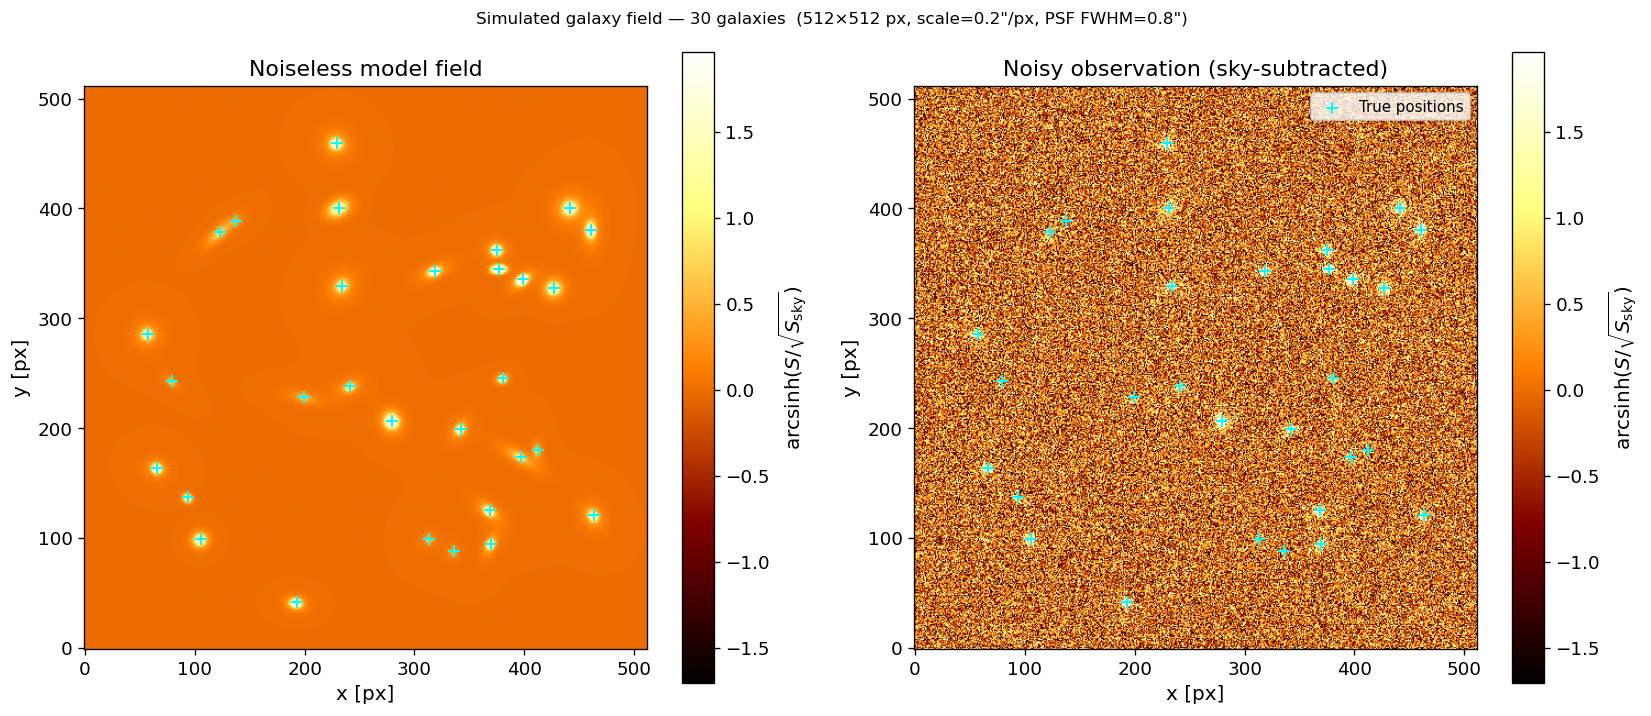

In [8]:
# ── Visualise the field ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stretch using arcsinh for better visibility of faint sources
sky_sub = image_data - SKY_LEVEL  # sky-subtracted
stretch = lambda arr: np.arcsinh(arr / np.sqrt(SKY_LEVEL))

for ax, (arr, title) in zip(axes, [
    (noiseless, 'Noiseless model field'),
    (sky_sub,   'Noisy observation (sky-subtracted)'),
]):
    vmin, vmax = np.percentile(stretch(sky_sub), [0.5, 99.8])
    im = ax.imshow(stretch(arr), origin='lower', cmap='afmhot', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=r'arcsinh$(S / \sqrt{S_{\rm sky}})$')

    # Mark input galaxy positions
    ax.scatter(cat['x_px'], cat['y_px'], marker='+', color='cyan',
               s=60, lw=1.2, label='True positions')
    ax.set_xlabel('x [px]')
    ax.set_ylabel('y [px]')
    ax.set_title(title)

axes[1].legend(fontsize=9)

plt.suptitle(f'Simulated galaxy field — {N_GALAXIES} galaxies  '
             f'({IMAGE_SIZE}×{IMAGE_SIZE} px, scale={PIXEL_SCALE}"/px, '
             f'PSF FWHM={PSF_FWHM}")', fontsize=10)
plt.tight_layout()
plt.savefig('galsim_field.pdf', bbox_inches='tight')
plt.show()

---

## 11. Source Detection with photutils

We follow the standard pipeline:
1. **Estimate and subtract the background** using a 2D background map.
2. **Detect connected regions** above $2.5\,\sigma_\text{bg}$ covering at least 10 pixels.
3. **Build a source catalogue** with positions, fluxes, and shape parameters.
4. **Cross-match** with the input catalogue to assess completeness and purity.

In [9]:
# ── Step 1: Background estimation ────────────────────────────────────────────
# Divide image into a grid of boxes; estimate median in each box.
# box_size should be larger than typical sources but smaller than any
# large-scale sky gradient.

bkg_estimator = MedianBackground()
bkg = Background2D(
    image_data,
    box_size    = 64,    # grid box size in pixels
    filter_size = 3,     # smooth the background map with a 3×3 median filter
    bkg_estimator = bkg_estimator,
)

bkg_level = bkg.background          # 2D background map (counts)
bkg_rms   = bkg.background_rms      # 2D background RMS map (counts)

# Sky-subtracted image
image_sub = image_data - bkg_level

print(f'Background estimation:')
print(f'  Mean background level : {bkg_level.mean():.1f} counts  (true sky = {SKY_LEVEL})')
print(f'  Mean background RMS   : {bkg_rms.mean():.1f} counts  (expected ≈ {np.sqrt(SKY_LEVEL):.1f})')
print(f'  Sky-subtracted image mean: {image_sub.mean():.2f} counts  (should ≈ 0)')

Background estimation:
  Mean background level : 200.1 counts  (true sky = 200.0)
  Mean background RMS   : 14.9 counts  (expected ≈ 14.1)
  Sky-subtracted image mean: 0.30 counts  (should ≈ 0)


In [10]:
# ── Step 2: Source detection ──────────────────────────────────────────────────
# Detect pixels > threshold = 2.5 × bkg_rms, in connected groups of ≥ 10 px.

DETECT_THRESH  = 2.5   # sigma above background
MIN_AREA_PX    = 10    # minimum source area in pixels

threshold = DETECT_THRESH * bkg_rms

segm = detect_sources(
    image_sub,
    threshold = threshold,
    npixels   = MIN_AREA_PX,
)

print(f'Detection threshold: {DETECT_THRESH}σ above background')
print(f'Minimum source area: {MIN_AREA_PX} pixels')
print(f'Number of detected sources: {segm.nlabels}')
print(f'Input galaxies             : {N_GALAXIES}')

Detection threshold: 2.5σ above background
Minimum source area: 10 pixels
Number of detected sources: 16
Input galaxies             : 30


In [11]:
# ── Step 3: Source catalogue ──────────────────────────────────────────────────
cat_det = SourceCatalog(image_sub, segm, background=bkg_level)

# Extract key measurements (photutils ≥ 1.0 attribute names)
x_det    = cat_det.x_centroid              # x pixel centroid
y_det    = cat_det.y_centroid              # y pixel centroid
flux_det = cat_det.segment_flux            # sum of pixels in segment (counts)
a_det    = cat_det.semimajor_axis.value    # 1-sigma semi-major axis [px] (2nd moment)
b_det    = cat_det.semiminor_axis.value    # 1-sigma semi-minor axis [px]

print(f'Detected source properties:')
print(f'  x_centroid: {x_det.min():.1f} – {x_det.max():.1f} px')
print(f'  y_centroid: {y_det.min():.1f} – {y_det.max():.1f} px')
print(f'  Flux      : {flux_det.min():.0f} – {flux_det.max():.0f} counts')
print(f'  Semi-major: {a_det.min():.2f} – {a_det.max():.2f} px')

Detected source properties:
  x_centroid: 56.9 – 462.6 px
  y_centroid: 41.2 – 458.9 px
  Flux      : 529 – 3982 counts
  Semi-major: 1.41 – 2.26 px


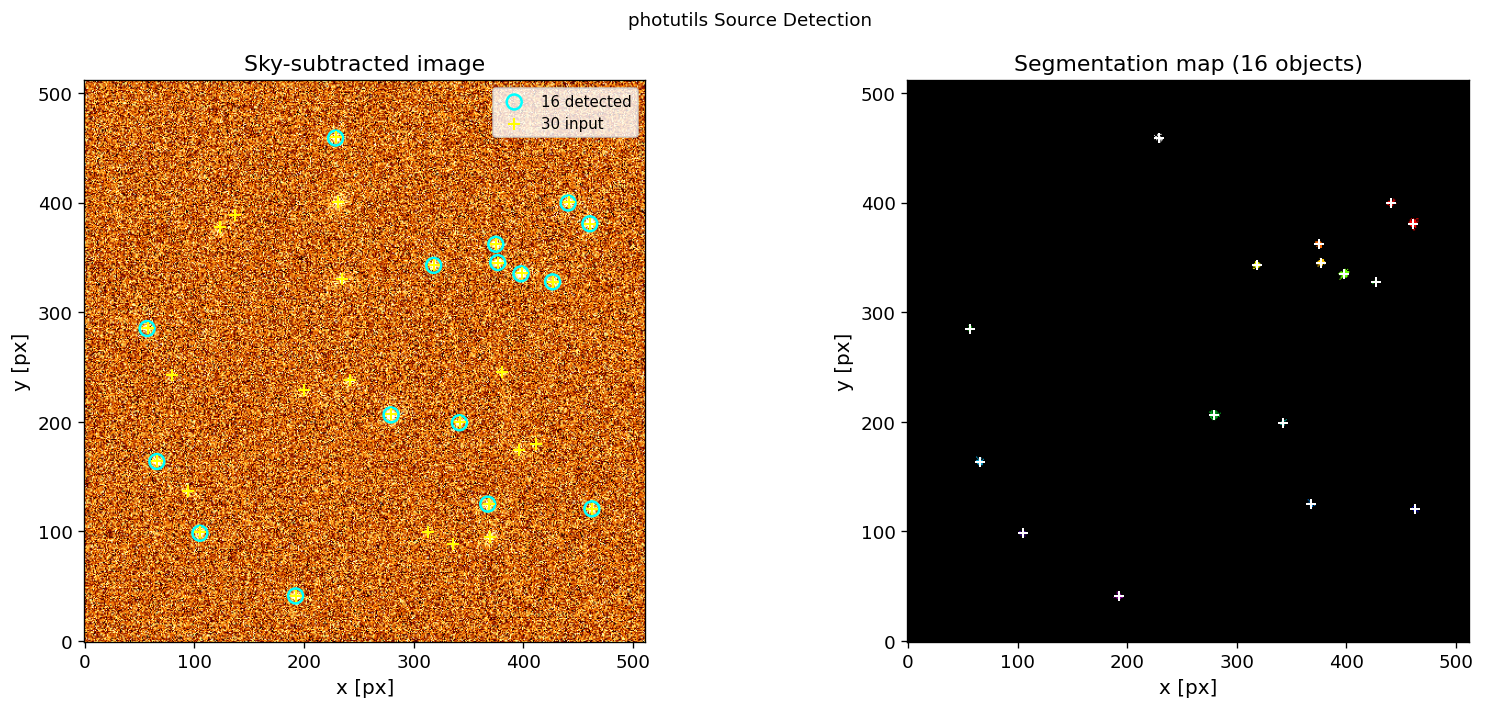

In [12]:
# ── Figure: segmentation map + detections overlaid ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sky-subtracted image
ax = axes[0]
vmin, vmax = np.percentile(image_sub, [1, 99.5])
ax.imshow(image_sub, origin='lower', cmap='afmhot', vmin=vmin, vmax=vmax)
ax.scatter(x_det, y_det, marker='o', facecolors='none', edgecolors='cyan',
           s=80, lw=1.5, label=f'{segm.nlabels} detected')
ax.scatter(cat['x_px'], cat['y_px'], marker='+', color='yellow',
           s=60, lw=1.2, label=f'{N_GALAXIES} input')
ax.set_title('Sky-subtracted image')
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(fontsize=9)

# Segmentation map
ax = axes[1]
ax.imshow(segm.data, origin='lower', cmap='nipy_spectral',
          vmin=0, vmax=segm.nlabels)
ax.scatter(x_det, y_det, marker='+', color='white', s=40, lw=1.2)
ax.set_title(f'Segmentation map ({segm.nlabels} objects)')
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')

plt.suptitle('photutils Source Detection', fontsize=11)
plt.tight_layout()
plt.savefig('galsim_detection.pdf', bbox_inches='tight')
plt.show()

In [13]:
# ── Cross-match: nearest detected source to each input galaxy ─────────────────
from scipy.spatial import cKDTree

MATCH_RADIUS_PX = 5.0  # maximum match radius in pixels

det_coords = np.column_stack([x_det, y_det])
inp_coords = np.column_stack([cat['x_px'], cat['y_px']])

tree = cKDTree(det_coords)
dists, idx_match = tree.query(inp_coords, distance_upper_bound=MATCH_RADIUS_PX)

matched = dists < MATCH_RADIUS_PX
n_matched = matched.sum()

print(f'Cross-match results (match radius = {MATCH_RADIUS_PX} px):')
print(f'  Input galaxies        : {N_GALAXIES}')
print(f'  Detected sources      : {segm.nlabels}')
print(f'  Matched (input→det)   : {n_matched}')
print(f'  Completeness          : {n_matched / N_GALAXIES * 100:.0f}%')
print(f'  Missed galaxies       : {N_GALAXIES - n_matched}')

Cross-match results (match radius = 5.0 px):
  Input galaxies        : 30
  Detected sources      : 16
  Matched (input→det)   : 16
  Completeness          : 53%
  Missed galaxies       : 14


---

## 12. Galaxy Profile Fitting

For each matched detection we:
1. Cut a small **postage stamp** (48×48 px) around the galaxy.
2. Build an initial guess for the Sérsic parameters from the segmentation catalogue.
3. Fit `astropy.modeling.models.Sersic2D` using Levenberg–Marquardt least squares.
4. Store the best-fit parameters and compare to the truth.

> **Note:** We fit in image space without PSF deconvolution here. This biases $r_e$ slightly upward for the most compact galaxies. In research one would convolve the model with the PSF before comparing to the data (as GALFIT does).

In [14]:
from astropy.modeling.models import Sersic2D

STAMP_HALF = 24  # half-size of fitting stamp in pixels

results = []

fitter = fitting.LevMarLSQFitter()

for i in range(N_GALAXIES):
    if not matched[i]:
        continue

    # Centroid from detection catalogue
    j_det = idx_match[i]
    xc = x_det[j_det]
    yc = y_det[j_det]

    # Cut a stamp from sky-subtracted image
    xi0 = int(np.round(xc)) - STAMP_HALF
    xi1 = int(np.round(xc)) + STAMP_HALF
    yi0 = int(np.round(yc)) - STAMP_HALF
    yi1 = int(np.round(yc)) + STAMP_HALF

    # Skip stamps that go outside the image
    if xi0 < 0 or yi0 < 0 or xi1 >= IMAGE_SIZE or yi1 >= IMAGE_SIZE:
        continue

    stamp = image_sub[yi0:yi1, xi0:xi1].copy()
    stamp_size_y, stamp_size_x = stamp.shape

    # Pixel coordinate grids (relative to stamp)
    yy, xx = np.mgrid[0:stamp_size_y, 0:stamp_size_x]
    xc_stamp = xc - xi0
    yc_stamp = yc - yi0

    # Noise map for weighting
    sigma_map = np.sqrt(np.abs(stamp) + SKY_LEVEL + READ_NOISE**2)

    # Initial guess: take r_e from second-moment size, n=2 (neutral)
    r_e_guess = max(a_det[j_det] * PIXEL_SCALE, 0.3)  # arcsec
    r_e_guess_px = r_e_guess / PIXEL_SCALE

    model_init = Sersic2D(
        amplitude    = stamp.max(),
        r_eff        = r_e_guess_px,
        n            = 2.0,
        x_0          = xc_stamp,
        y_0          = yc_stamp,
        ellip        = 1 - b_det[j_det] / max(a_det[j_det], 0.5),
        theta        = 0.0,
        bounds={
            'n':         (0.3, 8.0),
            'r_eff':     (0.5, STAMP_HALF * 0.9),
            'ellip':     (0.0, 0.95),
            'amplitude': (0.0, None),
        }
    )

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model_fit = fitter(model_init, xx, yy, stamp,
                               weights=1.0 / sigma_map, maxiter=500)

        results.append({
            'i_input'   : i,
            'n_in'      : cat['n_true'][i],
            'r_e_in'    : cat['r_e_true'][i],
            'flux_in'   : cat['flux_true'][i],
            'q_in'      : cat['q_true'][i],
            'n_out'     : model_fit.n.value,
            'r_e_out'   : model_fit.r_eff.value * PIXEL_SCALE,  # → arcsec
            'flux_out'  : flux_det[j_det],
            'q_out'     : 1 - model_fit.ellip.value,
            'model_fit' : model_fit,
            'stamp'     : stamp,
            'xi0'       : xi0, 'yi0': yi0,
            'xc_stamp'  : xc_stamp, 'yc_stamp': yc_stamp,
        })
    except Exception:
        pass

print(f'Successfully fitted: {len(results)} / {n_matched} matched galaxies')

Successfully fitted: 16 / 16 matched galaxies


Galaxy  1:  n_in=3.51 → n_out=2.73   r_e_in=0.48" → r_e_out=0.60"
Galaxy  2:  n_in=2.62 → n_out=2.69   r_e_in=1.14" → r_e_out=0.74"
Galaxy  4:  n_in=3.94 → n_out=3.50   r_e_in=0.76" → r_e_out=0.70"
Galaxy  6:  n_in=2.99 → n_out=3.85   r_e_in=1.06" → r_e_out=0.60"


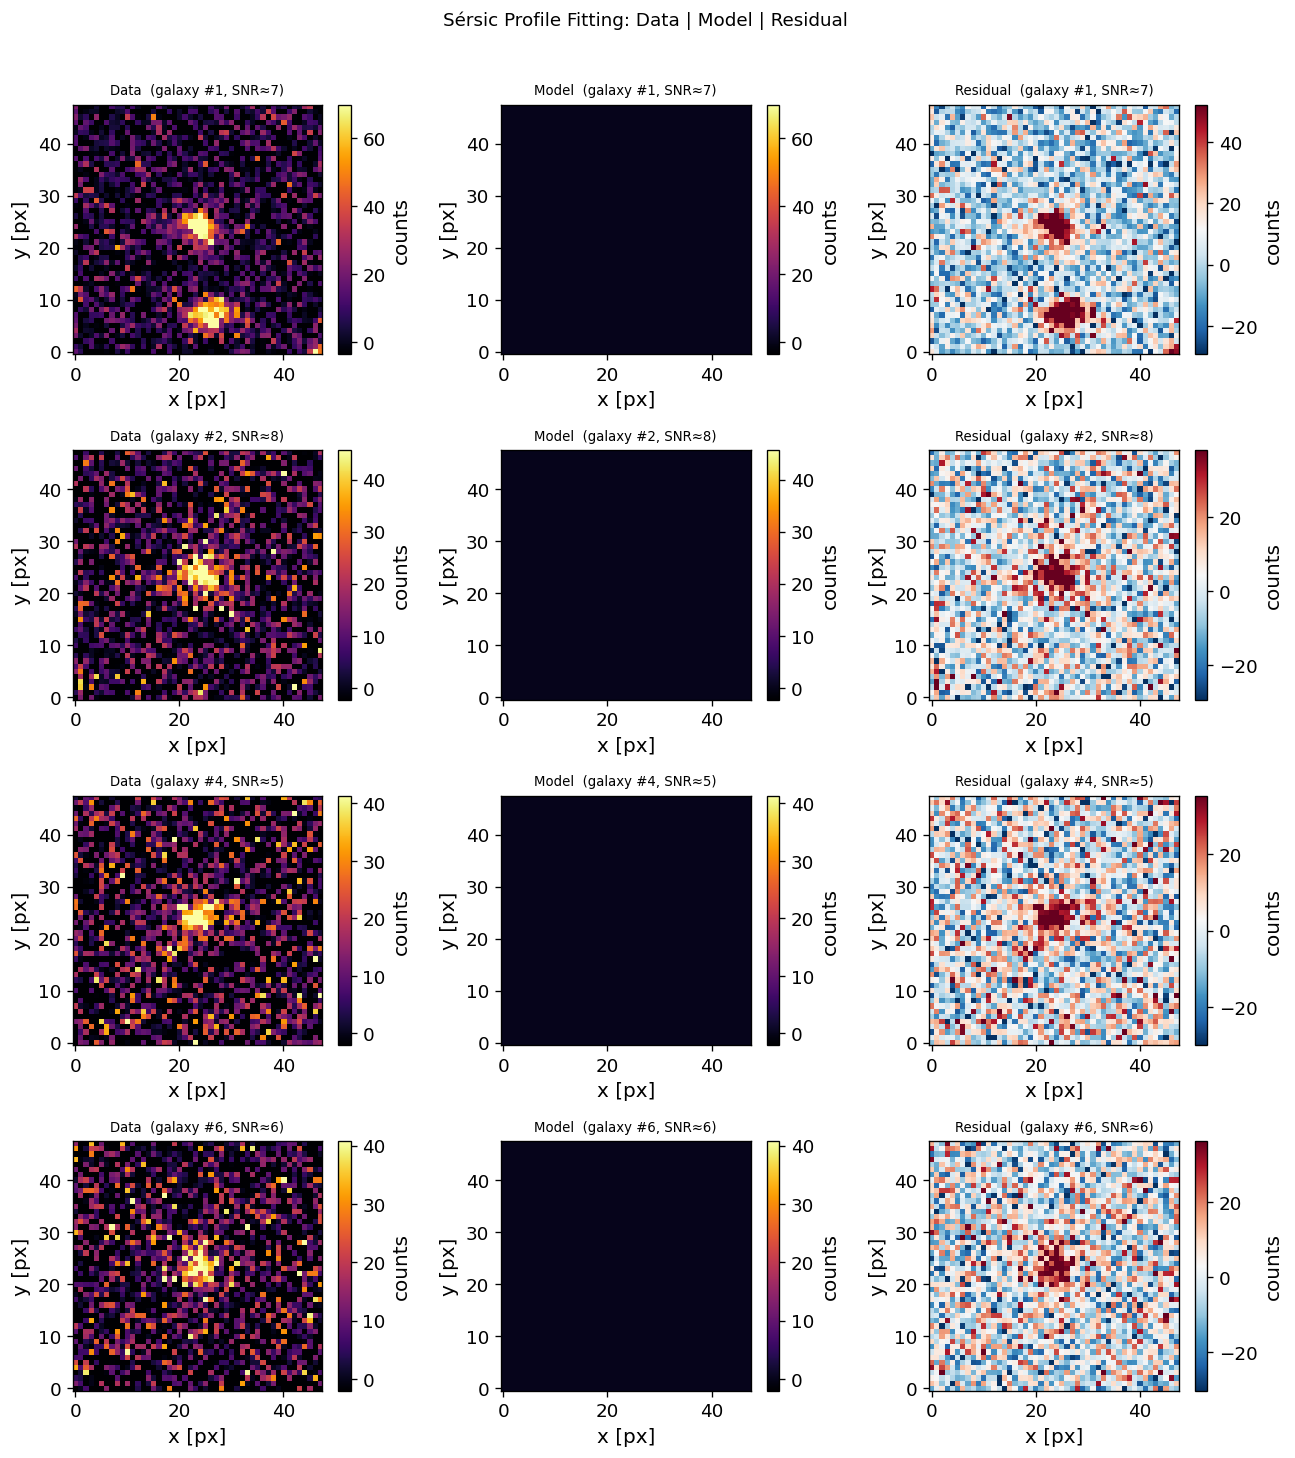

In [15]:
# ── Figure: data / model / residual for 4 galaxies ───────────────────────────
N_SHOW = min(4, len(results))
fig, axes = plt.subplots(N_SHOW, 3, figsize=(11, 3 * N_SHOW))

for row, res in enumerate(results[:N_SHOW]):
    stamp = res['stamp']
    mfit  = res['model_fit']
    yy_s, xx_s = np.mgrid[0:stamp.shape[0], 0:stamp.shape[1]]
    model_arr   = mfit(xx_s, yy_s)
    resid_arr   = stamp - model_arr

    vmax = np.percentile(stamp, 99)
    vmin_r, vmax_r = np.percentile(resid_arr, [2, 98])

    for col, (arr, title, cmap, vlo, vhi) in enumerate([
        (stamp,      'Data',     'inferno',  -0.05*vmax, vmax),
        (model_arr,  'Model',    'inferno',  -0.05*vmax, vmax),
        (resid_arr,  'Residual', 'RdBu_r',   vmin_r,     vmax_r),
    ]):
        ax = axes[row, col]
        im = ax.imshow(arr, origin='lower', cmap=cmap, vmin=vlo, vmax=vhi)
        plt.colorbar(im, ax=ax, label='counts')
        snr_gal = res['flux_in'] / np.sqrt(res['flux_in'] + stamp.size * SKY_LEVEL)
        ax.set_title(f'{title}  (galaxy #{res["i_input"]+1}, SNR≈{snr_gal:.0f})', fontsize=8)
        ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')

    # Print fit parameters for this galaxy
    print(f'Galaxy {res["i_input"]+1:2d}:  '
          f'n_in={res["n_in"]:.2f} → n_out={res["n_out"]:.2f}   '
          f'r_e_in={res["r_e_in"]:.2f}" → r_e_out={res["r_e_out"]:.2f}"')

plt.suptitle('Sérsic Profile Fitting: Data | Model | Residual', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('galsim_fitting_triptych.pdf', bbox_inches='tight')
plt.show()

---

## 13. Input–Output Comparison

We now compare the **recovered** parameters to the **true** input values. A perfect recovery would lie on the $y = x$ (one-to-one) line. Scatter around this line quantifies the **measurement uncertainty**; systematic offset is **bias**.

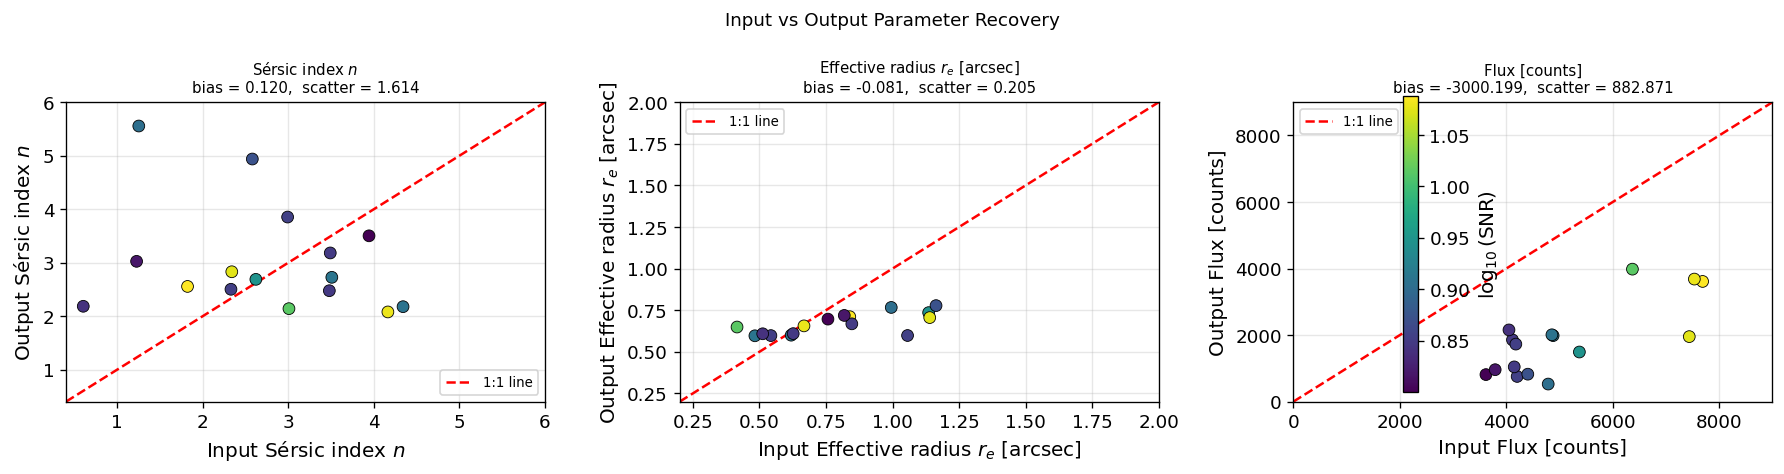


Parameter recovery summary:
Parameter             Median bias    RMS scatter
--------------------------------------------------
Sérsic n                   +0.120          1.614
r_e [arcsec]               -0.081          0.205
Flux [counts]           -3000.199        882.871


In [16]:
if len(results) < 3:
    print('Too few fitted galaxies for statistics — adjust detection parameters.')
else:
    n_in    = np.array([r['n_in']    for r in results])
    n_out   = np.array([r['n_out']   for r in results])
    re_in   = np.array([r['r_e_in']  for r in results])
    re_out  = np.array([r['r_e_out'] for r in results])
    fi      = np.array([r['flux_in'] for r in results])
    fo      = np.array([r['flux_out']for r in results])

    # Per-galaxy SNR (rough estimate: total signal / sqrt(sky in stamp))
    snr_arr = fi / np.sqrt(fi + (2 * STAMP_HALF)**2 * SKY_LEVEL)

    # ── Figure: 3 panels ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    panel_data = [
        (n_in,   n_out,  [0.4, 6], r'Sérsic index $n$'),
        (re_in,  re_out, [0.2, 2], r'Effective radius $r_e$ [arcsec]'),
        (fi,     fo,     [0, 9000], 'Flux [counts]'),
    ]

    for ax, (x, y, lim, lbl) in zip(axes, panel_data):
        sc = ax.scatter(x, y, c=np.log10(snr_arr + 1), cmap='viridis',
                        s=50, edgecolors='k', lw=0.5, zorder=3)
        ax.plot(lim, lim, 'r--', lw=1.5, label='1:1 line')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel(f'Input {lbl}')
        ax.set_ylabel(f'Output {lbl}')

        # Bias and scatter
        delta = y - x
        ax.set_title(f'{lbl}\n'
                     f'bias = {np.median(delta):.3f},  '
                     f'scatter = {np.std(delta):.3f}', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.colorbar(sc, ax=axes, label=r'$\log_{10}(\mathrm{SNR})$', shrink=0.8)
    plt.suptitle('Input vs Output Parameter Recovery', fontsize=11)
    plt.tight_layout()
    plt.savefig('galsim_io_comparison.pdf', bbox_inches='tight')
    plt.show()

    # Summary table
    print('\nParameter recovery summary:')
    print(f'{"Parameter":<18} {"Median bias":>14} {"RMS scatter":>14}')
    print('-' * 50)
    for name, x, y in [('Sérsic n', n_in, n_out),
                        ('r_e [arcsec]', re_in, re_out),
                        ('Flux [counts]', fi, fo)]:
        d = y - x
        print(f'{name:<18} {np.median(d):>+14.3f} {np.std(d):>14.3f}')

---

## 14. Effect of SNR on Parameter Recovery

We expect recovery to degrade for faint (low-SNR) galaxies. Here we bin the results by SNR and show how bias and scatter evolve.

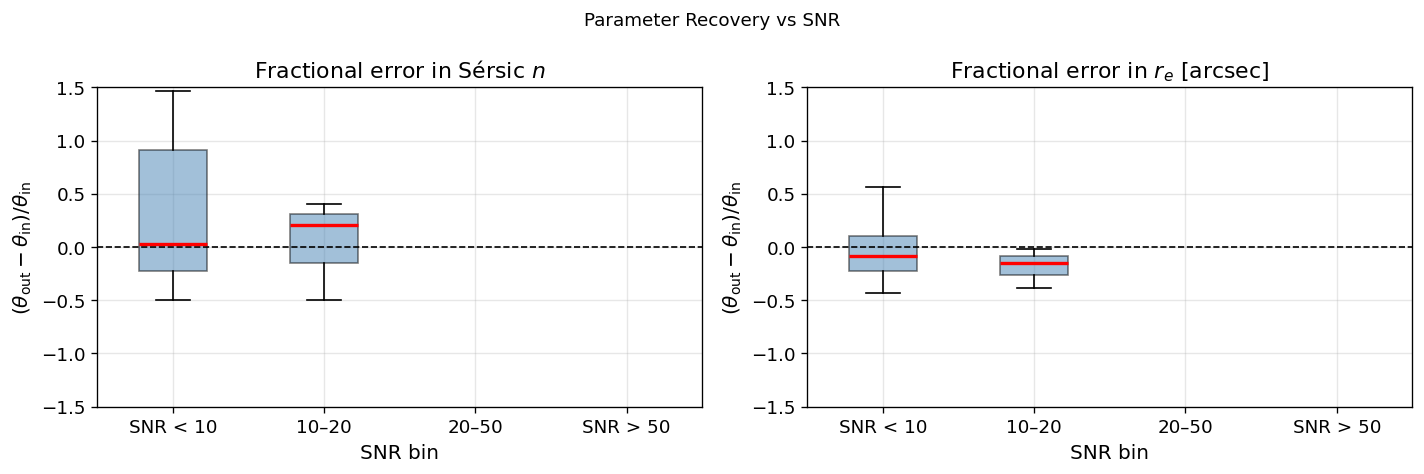

Observation: scatter grows and bias increases for low-SNR galaxies.
n is the hardest parameter to recover (it controls the profile shape).


In [17]:
if len(results) < 5:
    print('Too few fitted galaxies for SNR binning.')
else:
    snr_bins = [0, 10, 20, 50, 1e6]
    bin_labels = ['SNR < 10', '10–20', '20–50', 'SNR > 50']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (param_name, x_arr, y_arr) in zip(
        axes,
        [('Sérsic $n$', n_in, n_out), (r'$r_e$ [arcsec]', re_in, re_out)]
    ):
        fractional = (y_arr - x_arr) / x_arr
        bin_data = []
        for lo, hi in zip(snr_bins[:-1], snr_bins[1:]):
            mask = (snr_arr >= lo) & (snr_arr < hi)
            if mask.sum() > 0:
                bin_data.append(fractional[mask])
            else:
                bin_data.append(np.array([np.nan]))

        bp = ax.boxplot(bin_data, labels=bin_labels, patch_artist=True,
                        medianprops={'color': 'red', 'lw': 2})
        for patch in bp['boxes']:
            patch.set_facecolor('steelblue')
            patch.set_alpha(0.5)
        ax.axhline(0, color='k', lw=1, ls='--')
        ax.set_xlabel('SNR bin')
        ax.set_ylabel(r'$(\theta_\mathrm{out} - \theta_\mathrm{in}) / \theta_\mathrm{in}$')
        ax.set_title(f'Fractional error in {param_name}')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-1.5, 1.5)

    plt.suptitle('Parameter Recovery vs SNR', fontsize=11)
    plt.tight_layout()
    plt.savefig('galsim_snr_recovery.pdf', bbox_inches='tight')
    plt.show()

    print('Observation: scatter grows and bias increases for low-SNR galaxies.')
    print('n is the hardest parameter to recover (it controls the profile shape).')

---

## 15. Visualising the PSF Effect

A key insight: the PSF broadens profiles, making small galaxies harder to characterise. Here we show how much the PSF changes the observed profile compared to the true profile.

In [18]:
# -- True (intrinsic) profile: analytic Sersic formula -----------------------
# -- PSF-convolved profile: GalSim rendering ----------------------------------
# Note: analytic formula is used for the true profile to avoid GalSim FFT
#       issues when rendering compact profiles without PSF convolution.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (r_e_val, n_val, title) in zip(axes, [
    (0.3, 2.0, r'Small galaxy ($r_e = 0.3"$, $n=2$)'),
    (1.5, 2.0, r'Large galaxy ($r_e = 1.5"$, $n=2$)'),
]):
    # Analytic true profile (sersic_profile defined in section 7)
    r_max  = max(4.0, 5.0 * r_e_val)
    r_arr  = np.linspace(0.001, r_max, 500)
    I_true = sersic_profile(r_arr, n_val, r_e=r_e_val)
    I_true = I_true / I_true.max()

    # PSF-convolved profile via GalSim
    stamp_sz = 201
    gal_gs   = galsim.Sersic(n=n_val, half_light_radius=r_e_val, flux=1e5)
    conv_gs  = galsim.Convolve([gal_gs, galsim.Gaussian(fwhm=PSF_FWHM)])
    img_c    = galsim.Image(stamp_sz, stamp_sz, scale=PIXEL_SCALE)
    conv_gs.drawImage(image=img_c)

    cx       = stamp_sz // 2
    row_conv = img_c.array[cx, :]
    x_arcsec = (np.arange(stamp_sz) - cx) * PIXEL_SCALE
    mask     = (x_arcsec >= 0) & (x_arcsec <= r_max)
    peak     = max(row_conv.max(), 1e-30)

    ax.plot(r_arr,           I_true,              'b-', lw=2, label='True Sersic (analytic)')
    ax.plot(x_arcsec[mask],  row_conv[mask]/peak, 'r-', lw=2, label='PSF-convolved (GalSim)')
    ax.axvline(r_e_val,      color='gray',  ls='--', lw=1,   label=f'$r_e = {r_e_val}"$')
    ax.axvline(PSF_FWHM / 2, color='green', ls=':',  lw=1.2, label=f'PSF HWHM = {PSF_FWHM/2}"')
    ax.set_xlabel('Radius [arcsec]')
    ax.set_ylabel('Normalised surface brightness')
    ax.set_title(title)
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'PSF Effect on Observed Profiles  (PSF FWHM = {PSF_FWHM}")', fontsize=11)
plt.tight_layout()
plt.savefig('galsim_psf_effect.pdf', bbox_inches='tight')
plt.show()

print('Key result: the small galaxy (r_e < PSF HWHM) is essentially unresolved.')
print('Its observed profile is dominated by the PSF shape, not the galaxy shape.')


ValueError: 
Small galaxy ($r_e = 0.3"$, $n=2$)
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

Error in callback <function _draw_all_if_interactive at 0x795383cb9da0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
Small galaxy ($r_e = 0.3"$, $n=2$)
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

ValueError: 
Small galaxy ($r_e = 0.3"$, $n=2$)
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

<Figure size 1440x480 with 2 Axes>

---

## 16. Professional Tools: GALFIT and GALFITools

The approach in this notebook (Sérsic fit with `astropy.modeling`) is instructive but simplified. In research, the standard tool is **GALFIT** (Peng et al. 2002, 2010), which:

- Fits **multiple Sérsic components** simultaneously (bulge + disk + bar + …).
- **Convolves the model with the PSF** at every iteration (essential for compact galaxies).
- Supports many more profile types: Nuker, Gaussian, Moffat, Exponential, Ferrer, King, …
- Provides per-parameter uncertainties from the covariance matrix.

[**GALFITools**](https://pypi.org/project/GALFITools/) (C. Añorve) is a Python package that wraps GALFIT: it creates the input `.feedme` configuration files, runs GALFIT, reads the output `.fits` files, and provides analysis and mask-creation utilities.

```python
# Example workflow (requires GALFIT binary installed on your system):
# pip install GALFITools

# from galfittools import GALFITools
# gft = GALFITools()
# gft.RunGALFIT(feedme='galaxy.feedme')
# result = gft.ReadOutput('galaxy_out.fits')
# print(result.sersic.n, result.sersic.re)
```

GALFIT itself (compiled binary, free for academic use) must be downloaded separately from [https://users.obs.carnegiescience.edu/peng/work/galfit/galfit.html](https://users.obs.carnegiescience.edu/peng/work/galfit/galfit.html).

---

## 17. Summary

### Key concepts

| Concept | Formula / tool | Take-away |
|---------|---------------|----------|
| Sérsic profile | $I(r) = I_e \exp\{-b_n[(r/r_e)^{1/n}-1]\}$ | $n, r_e, I_e$ fully describe a galaxy's brightness profile |
| PSF convolution | $I_\text{obs} = I_\text{true} * \text{PSF}$ | Atmospheric blurring smears and broadens the profile |
| Image noise | $\sigma^2 = N_\text{gal} + N_\text{sky} + \sigma^2_\text{read}$ | Noise limits the precision of parameter recovery |
| Detection | `photutils.detect_sources` | Connected-component labelling above $k\sigma$ threshold |
| Profile fitting | $\chi^2 = \sum (I - M)^2/\sigma^2$ | Levenberg–Marquardt minimisation via `astropy.modeling` |
| Parameter recovery | scatter($n$) $>$ scatter($r_e$) | Shape ($n$) is harder to recover than size ($r_e$) |

### Workflow recap

```
GalSim: define Sérsic → shear → shift → convolve PSF → draw pixels → add noise
   ↓
photutils: estimate background → subtract → detect sources → build catalogue
   ↓
astropy.modeling: cut stamp → fit Sersic2D → residuals → compare to truth
```

### Further reading

- **GalSim documentation:** [https://galsim-developers.github.io/GalSim/_build/html/index.html](https://galsim-developers.github.io/GalSim/_build/html/index.html)
- **photutils documentation:** [https://photutils.readthedocs.io/en/stable/](https://photutils.readthedocs.io/en/stable/)
- **Sérsic profiles review:** Graham & Driver (2005), PASA 22, 118 — [arXiv:astro-ph/0503176](https://arxiv.org/abs/astro-ph/0503176)
- **GALFIT paper:** Peng et al. (2002), AJ 124, 266 — [arXiv:astro-ph/0204182](https://arxiv.org/abs/astro-ph/0204182)
- **GalSim paper:** Rowe et al. (2015), A&C 10, 121 — [arXiv:1407.7676](https://arxiv.org/abs/1407.7676)

---

## 18. Exercises

1. **PSF size effect** *(easy)*: Change `PSF_FWHM` from 0.8" to 0.3" (sharper seeing) and 2.0" (poor seeing). How does completeness and parameter recovery change? Which galaxies become unresolved?

2. **Sérsic index recovery** *(medium)*: Fix all galaxy parameters to $n = 1$ (pure disks) and re-run the simulation and fitting. Plot the distribution of recovered $n_\text{out}$ values. What does the spread tell you about the measurement uncertainty?

3. **Background subtraction failure** *(medium)*: Simulate a strong sky gradient by adding `0.5 * np.arange(IMAGE_SIZE)` to each row of the image before detection. How does this affect the number of detections and the flux measurements? Fix it by adjusting the background estimation parameters.

4. **Deblending** *(hard)*: Simulate two galaxies with overlapping profiles (place them within 5 arcsec of each other). The standard `detect_sources` will likely merge them into one object. Look at the `photutils.segmentation.deblend_sources` function and use it to separate the pair. Check whether the fit improves.

5. **PSF-corrected fitting** *(hard)*: Modify the fitting loop to convolve the Sérsic model with the PSF kernel (`astropy.convolution.convolve_fft`) before comparing to the data. Quantify how much this reduces the bias in $r_e$ for the most compact galaxies ($r_e < 0.5''$).